# **Raquel Marques - Text Mining Project**

Last Updated: 2026-05-17

---

# <span style="color:blue">Business Context</span>

A Brazilian news aggregation platform needs to automatically categorize articles from *Folha de S.Paulo*, eliminating the manual editorial curation process that currently consumes around 40 hours per week.

You are the data scientist responsible for building, comparing, and recommending the best production-ready approach. The system must achieve a macro F1-score ≥ 0.75 to be considered operationally viable.

**Dataset**
- Source: Kaggle - [News of the Brazilian Newspaper](kaggle.com/datasets/marlesson/news-of-the-site-folhauol)
- File: articles.csv
- Columns: id, url, title, text, category
- Volume: ~167,000 articles across 48 categories


Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

## Initial Setup

- Library
- Path
- Dataset

In [82]:
# LIBRARY
import os
import kagglehub
import time

import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re                          # regular expression
from collections import Counter    # count elements frequency
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# print(kagglehub.__version__)

In [2]:
# PATH
project_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code",
                           "ASN-DSA-T5", 
                           "31-TM",
                           "Project_1")



In [3]:
# DATASET
# Download data from Kaggle
dataset_path = kagglehub.dataset_download(
    "marlesson/news-of-the-site-folhauol",
    output_dir=os.path.join(project_dir, "data")
)

print(f"Downloaded to: {dataset_path}")


Downloaded to: C:\Users\kel_m\OneDrive\Project_Code\ASN-DSA-T5\31-TM\Project_1\data


In [4]:
# Ingest file
df = pd.read_csv(os.path.join(project_dir, "data", "articles.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   title        167053 non-null  str  
 1   text         166288 non-null  str  
 2   date         167053 non-null  str  
 3   category     167053 non-null  str  
 4   subcategory  29635 non-null   str  
 5   link         167053 non-null  str  
dtypes: str(6)
memory usage: 7.6 MB


In [5]:
df.head()

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


## Part 1: Dataset Exploration and Curation


In [6]:
# Q1
# Category Count
cat_count = df['category'].value_counts()
cat_count

# Imbalance Ratio
freq_more = cat_count.max()
freq_less = cat_count.min()
freq_ratio = freq_more / freq_less

print(f'Total categories: {df["category"].nunique()}')
print(f'Most frequent category: {freq_more}')
print(f'Less frequent category: {freq_less}')
print(f'Imbalance ratio: {freq_ratio:.2f}')

# Row count
total = cat_count.sum()


Total categories: 48
Most frequent category: 22022
Less frequent category: 1
Imbalance ratio: 22022.00


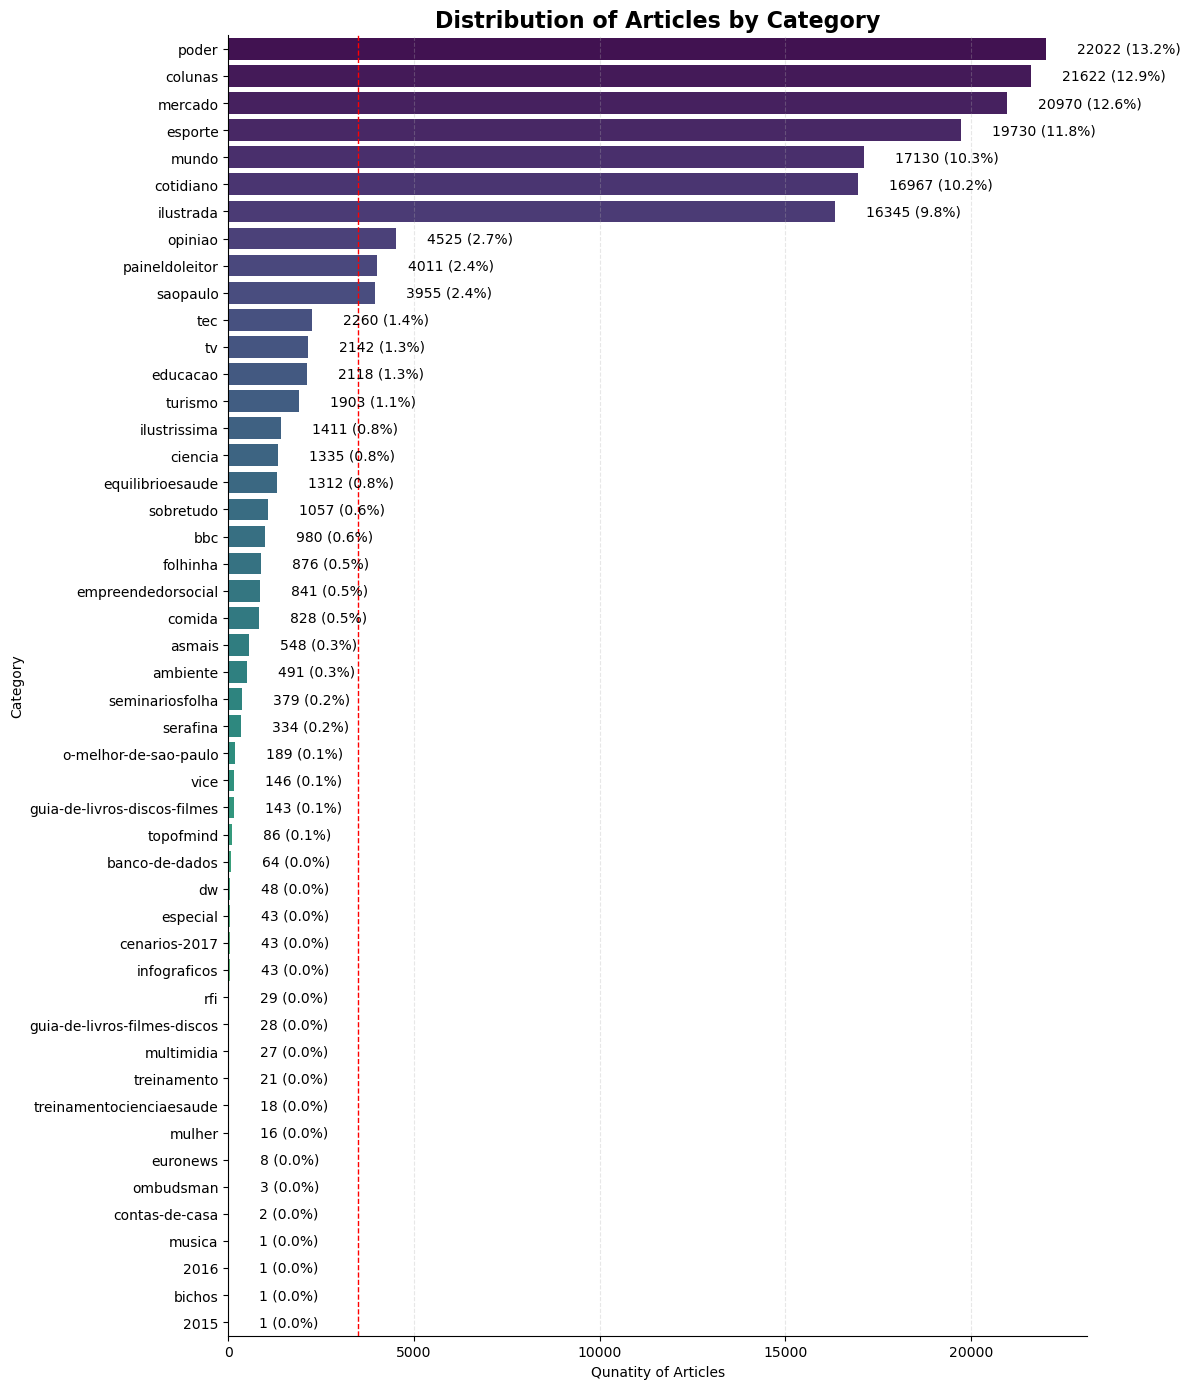

In [7]:
# Chart
plt.figure(figsize=(12,14))

ax = sns.barplot(
    x=cat_count.values,
    y=cat_count.index,
    hue=cat_count.index,
    palette='viridis',
    legend=False
)

# Avg Line
mean_value = cat_count.mean()
plt.axvline(mean_value, color='red', linestyle='--', linewidth=1)

# Labels + percentage
for i, v in enumerate(cat_count.values):
    percentage_value = (v / total) * 100
    ax.text(
        v + (total * 0.005),
        i,
        f'{v} ({percentage_value:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Distribution of Articles by Category', fontsize=16, weight='bold')
plt.xlabel('Qunatity of Articles')
plt.ylabel('Category')

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

### <span style="color:green">Q1. Class Distribution</span>

> Visualize the frequency of articles per category (all 48 categories). 
> - What is the level of class imbalance? 
> - Calculate the ratio between the most frequent and the least frequent category. 
> - What direct impact does this imbalance have on the choice of evaluation metric and on the training strategy?
>

The dataset presents an **extreme class imbalance**, with article frequencies varying substantially across the 48 categories. The most frequent category, *poder*, contains 22,022 articles, while the least frequent categories, *bichos* and *musica*, contain only 1 article each, resulting in an imbalance ratio of: $\frac{22022}{1} = 22022$ .

This means the largest class is **22,022 times more represented** than the smallest classes, characterizing the dataset as **extremely imbalanced**.

Such imbalance has a direct impact on both the evaluation strategy and the model training process:
- Evaluation Metrics:
    - Accuracy alone becomes unreliable because the model can achieve high overall accuracy by predicting only majority classes while ignoring minority ones. 
    - So, metrics such as Macro F1-score, Precision, Recall, and per-class evaluation are more appropriate, since they give equal importance to all classes regardless of frequency.
- Training Strategy:
    - The model may become biased toward dominant categories, reducing its ability to correctly classify rare classes. To mitigate this issue, techniques such as:
        - class weighting,
        - oversampling minority classes,
        - undersampling majority classes,
        - stratified train/test splits, 
        - or data augmentation may be necessary.

Additionally, categories with only one sample are problematic because the model cannot properly learn representative patterns from them, and these classes may even need to be removed or grouped depending on the modeling objective.

In [8]:
# Q2
# Calculate word count per TITLE and TEXT
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

title_mean = df['title_len'].mean()
text_mean = df['text_len'].mean()

C:\Users\kel_m\AppData\Local\Temp\ipykernel_43012\2589953902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kel_m\AppData\Local\Temp\ipykernel_43012\2589953902.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


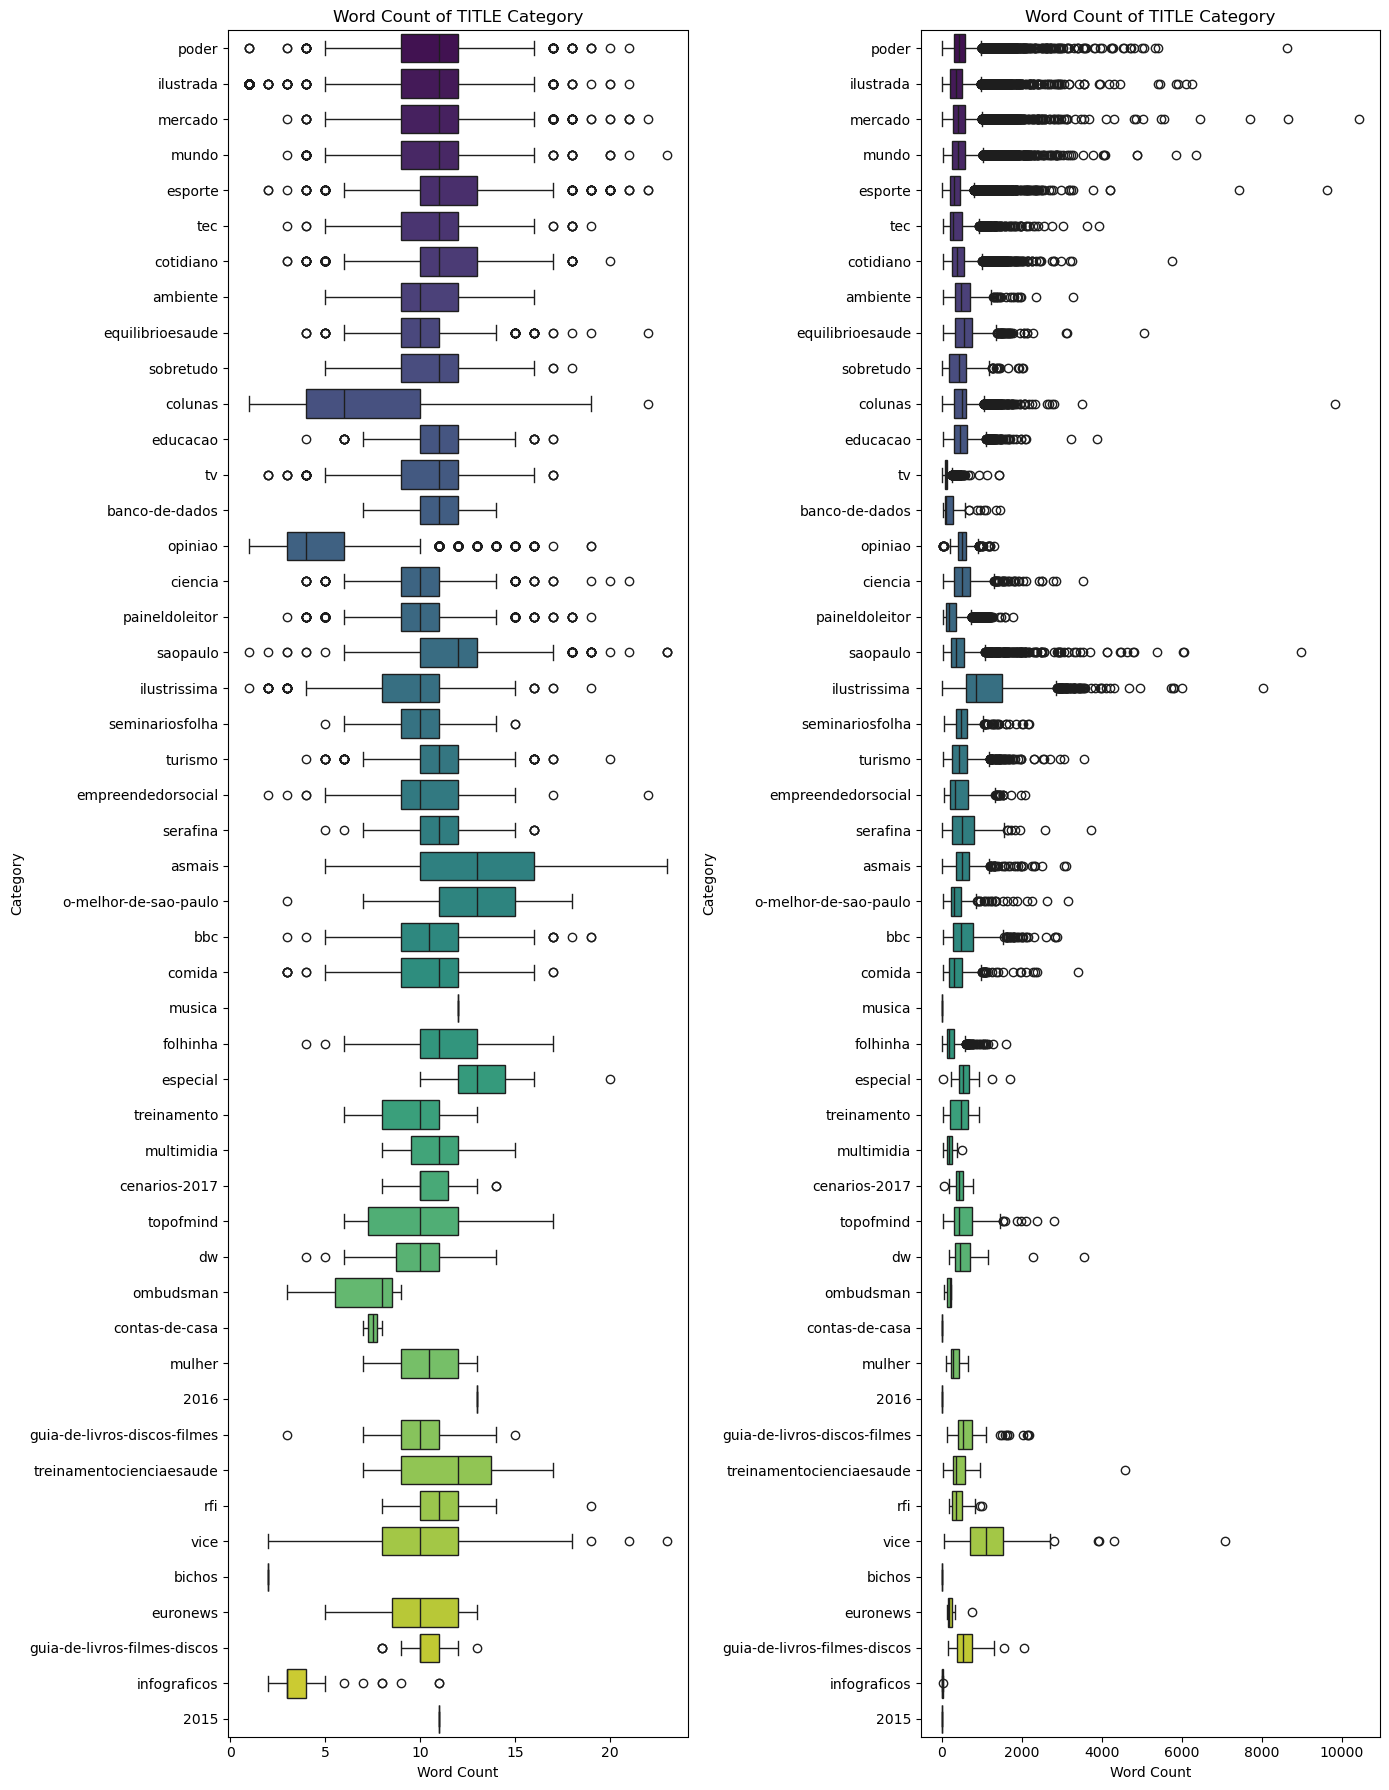

In [9]:
# Chart - combined
plt.figure(figsize=(14,18))

# Chart 1 - Word Count of TITLE by Category
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    y='category',
    x='title_len',
    palette='viridis'
)
plt.title('Word Count of TITLE Category')
plt.xlabel('Word Count')
plt.ylabel('Category')

# Chart 2 - Word Count of TEXT by Category
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    y='category',
    x='text_len',
    palette='viridis'
)
plt.title('Word Count of TITLE Category')
plt.xlabel('Word Count')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

     

C:\Users\kel_m\AppData\Local\Temp\ipykernel_43012\3774977350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


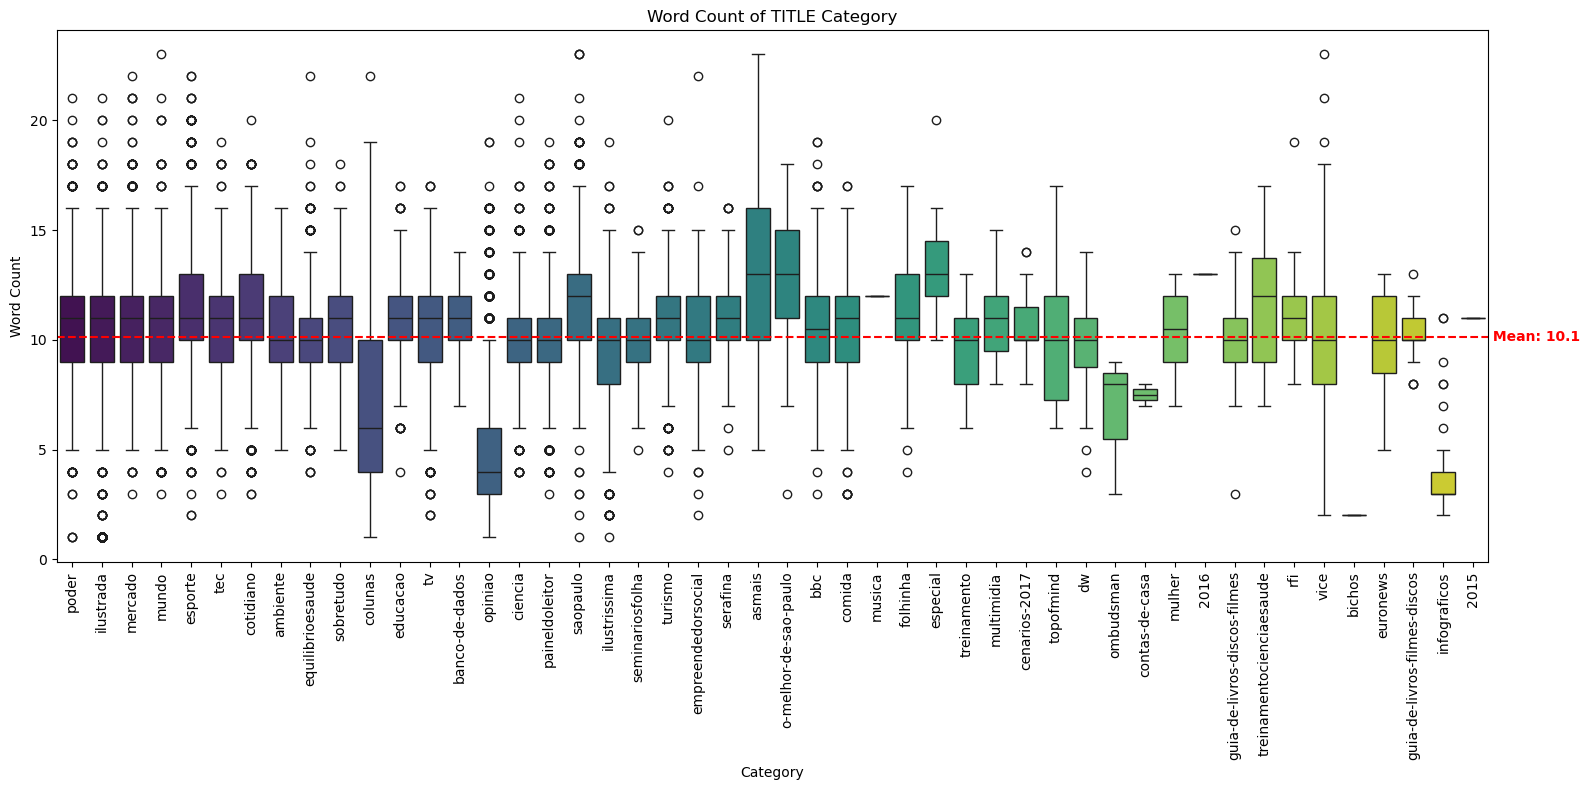

C:\Users\kel_m\AppData\Local\Temp\ipykernel_43012\3774977350.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


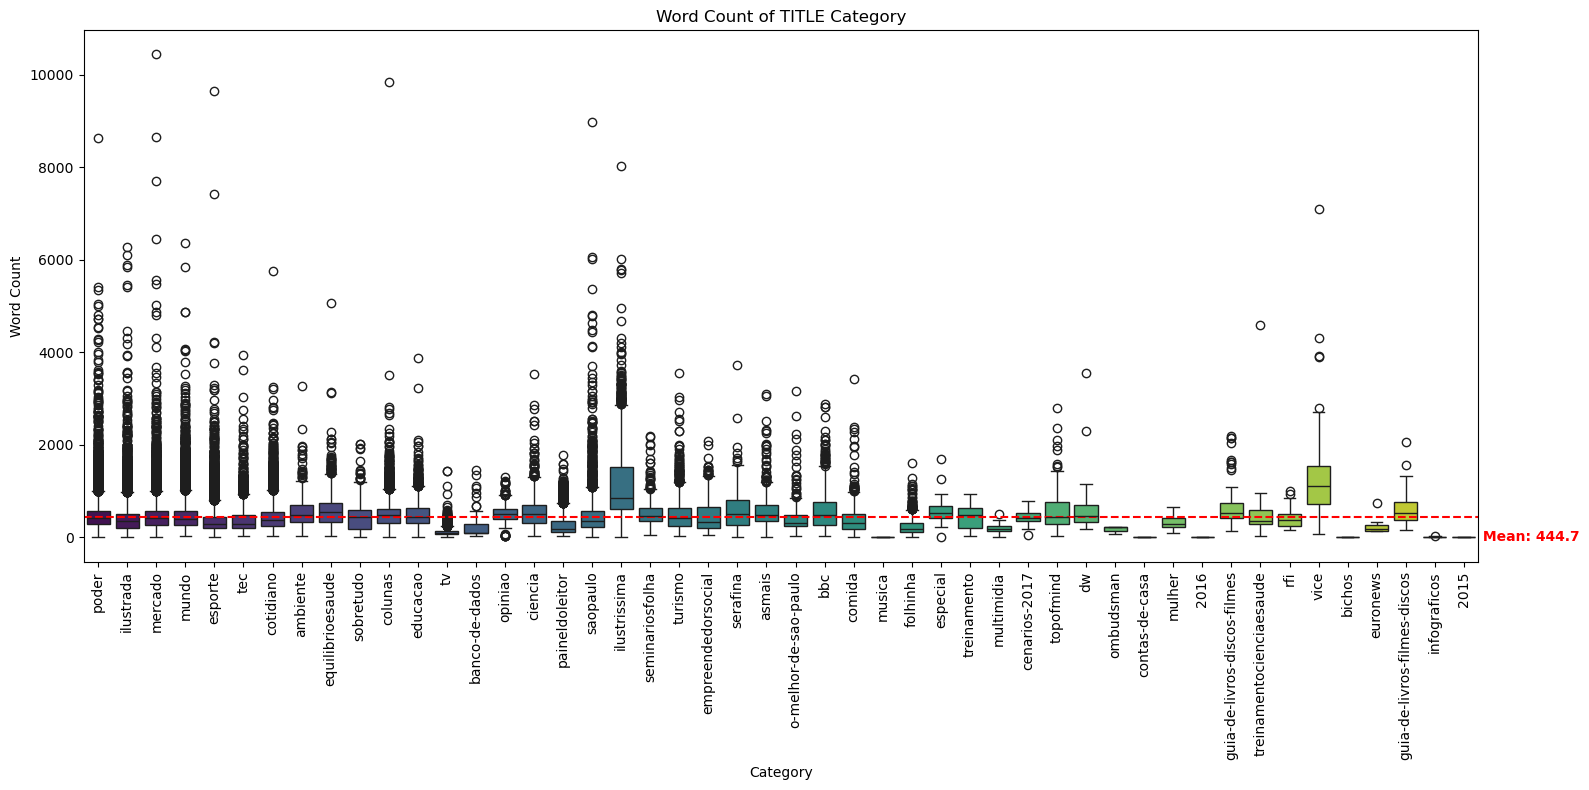

In [10]:
# Chart 1 - Word Count of TITLE by Category
plt.figure(figsize=(16, 8))
ax = sns.boxplot(
    data=df,
    x='category',
    y='title_len',
    palette='viridis'
)
ax.axhline(title_mean, color='red', linestyle='--')
ax.text(
    x=ax.get_xlim()[1],          # Places text at the far right of the x-axis
    y=title_mean,                # Vertical position matches the line
    s=f' Mean: {title_mean:.1f}', # The actual text
    color='red',                 # Match the line color
    va='center',                 # Vertical alignment: center on the line
    fontweight='bold'            # Optional styling
)

plt.title('Word Count of TITLE Category')
plt.ylabel('Word Count')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Chart 2 - Word Count of TEXT by Category
plt.figure(figsize=(16, 8))
ax = sns.boxplot(
    data=df,
    x='category',
    y='text_len',
    palette='viridis'
)
ax.axhline(text_mean, color='red', linestyle='--')
ax.text(
    x=ax.get_xlim()[1],          # Places text at the far right of the x-axis
    y=title_mean,                # Vertical position matches the line
    s=f' Mean: {text_mean:.1f}', # The actual text
    color='red',                 # Match the line color
    va='center',                 # Vertical alignment: center on the line
    fontweight='bold'            # Optional styling
)

plt.title('Word Count of TITLE Category')
plt.ylabel('Word Count')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
# Descriptive Statistics
# TITLE
summary_stats_title = df.groupby('category')['title_len'].agg(['count', 'median', 'mean', 'var', 'std']).round(2)
summary_stats_title = summary_stats_title.sort_values(by='median', ascending=False)

print("\nTitle Length Statistics by Category:")
print(summary_stats_title)


# TEXT
summary_stats_text = df.groupby('category')['text_len'].agg(['count', 'median', 'mean', 'var', 'std']).round(2)
summary_stats_text = summary_stats_text.sort_values(by='median', ascending=False)

print("\nText Length Statistics by Category:")
print(summary_stats_text)




Title Length Statistics by Category:
                              count  median   mean    var   std
category                                                       
2016                              1    13.0  13.00    NaN   NaN
asmais                          548    13.0  13.24  15.07  3.88
o-melhor-de-sao-paulo           189    13.0  13.05   4.94  2.22
especial                         43    13.0  13.09   3.75  1.94
saopaulo                       3955    12.0  11.73   4.63  2.15
musica                            1    12.0  12.00    NaN   NaN
treinamentocienciaesaude         18    12.0  11.61  10.13  3.18
2015                              1    11.0  11.00    NaN   NaN
esporte                       19730    11.0  11.34   3.54  1.88
mundo                         17130    11.0  10.57   3.04  1.74
mercado                       20970    11.0  10.80   3.86  1.96
banco-de-dados                   64    11.0  10.98   2.81  1.68
cotidiano                     16967    11.0  11.30   3.68  1.92
ed

### <span style="color:green">Q2. Text Anatomy</span>

> Compare the distribution of text length (in words) for both title and text across categories using boxplots or violin plots. 
> - Do any categories contain systematically shorter or longer texts? 
> - How does this influence your decision about which field to use as model input?
>

The distribution of text length reveals important differences between the `TITLE` and `TEXT` fields.

The `title` field presents relatively uniform lengths across categories, with an average of 10 words (median between 10 to 13) and low variability. Categories such as *2016*, *asmais*, *o-melhor-de-sao-paulo*, and *especial* have median lengths close to 13 words, while categories such as *ombudsman*, *contas-de-casa*, *colunas*, *opiniao*, *infograficos*, and *bichos* contain shorter titles. Overall, the title field follows a more standardized and consistent structure.

In contrast, the `text` field shows much greater variability both across categories and within the same category, indicating high dispersion and the presence of many outliers. Categories such as *vice*, *ilustrissima*, *equilibrioesaude*, and *colunas* tend to contain significantly longer texts, while categories such as *tv*, *infograficos*, *multimidia*, and *ombudsman* contain much shorter texts. In addition, some categories contain extremely short or even empty texts (*2015*, *2016*, *musica*, and *contas-de-casa*), highlighting inconsistencies in the dataset.

This difference directly influences the choice of input field for the model. The `text` field carries much richer semantic information for the classification task, allowing the model to better capture context and category-specific characteristics. On the other hand, the `title` field is more compact, less noisy, and may provide an additional useful signal, especially because journalistic headlines often summarize the main topic of the article.

Therefore, the most appropriate strategy is to:
- use the `text` field as the primary source of information;
- use the `title` field as complementary information, specially where the title better summarize the text, giving us a additional signal.

This approach is expected to improve the model’s discriminative capability and increase performance on metrics such as Macro F1-score, particularly for semantically similar categories.

In [12]:
# Q3
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese')) | {
        'pra','pro','ta','ja','né','ai','aih','ah','vc','vcs','tbm','tb',
        'sobre','hey','havia','neste','nesta','ter'}

# FUNCTION: Prepocessing cleaning
def preprocess(text):
    text = str(text).lower()                              # lower text
    text = re.sub(r'https?://\S+|www\.\S+', '', text)     # remove urls
    text = re.sub(r'\S+@\S+', '', text)                   # remove emails
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # remove spaces

    tokens = text.split()

    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # remove stopwords

    return tokens


# FUNCTION: Extract top tokens from a category
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()
    tokens = []

    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# FUNCTION: Calculate overlapping
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    shared = tokens1.intersection(tokens2)
    proportion = len(shared) / 20

    return tokens1, tokens2, shared, proportion


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kel_m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
print(stop_words)

{'esteja', 'houvéramos', 'tive', 'ja', 'seus', 'tuas', 'tém', 'estes', 'houveria', 'estava', 'terá', 'tenha', 'esteve', 'houvermos', 'muito', 'em', 'o', 'aquela', 'seríamos', 'ser', 'entre', 'seremos', 'tivéssemos', 'essa', 'teremos', 'até', 'fôramos', 'com', 'ele', 'houverão', 'aih', 'delas', 'as', 'houver', 'fôssemos', 'tbm', 'por', 'for', 'é', 'qual', 'havia', 'estou', 'do', 'de', 'havemos', 'pelos', 'lhe', 'houveriam', 'te', 'dele', 'tínhamos', 'nossas', 'houvéssemos', 'tiver', 'terei', 'houveríamos', 'nos', 'tivessem', 'vos', 'ai', 'meu', 'hei', 'estas', 'não', 'estivéssemos', 'num', 'estamos', 'nossa', 'esses', 'minha', 'houverei', 'temos', 'tiverem', 'tinham', 'nesta', 'né', 'está', 'sua', 'ter', 'estivemos', 'hão', 'houvessem', 'fosse', 'tenhamos', 'aqueles', 'sejam', 'nosso', 'será', 'houve', 'lhes', 'no', 'estivesse', 'elas', 'houvesse', 'já', 'foram', 'às', 'são', 'estivera', 'formos', 'teriam', 'isso', 'só', 'quem', 'ao', 'da', 'vcs', 'há', 'e', 'houveram', 'éramos', 'meus'

In [14]:
# Pair Analysis
pairs = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pairs:
    t1, t2, overlap_value, proportion_value = overlap(c1, c2)

    print(f'\n==> Categories: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Overlapping Tokens ({len(overlap_value)}): {list(overlap_value)} ')
    print(f'Overlap Proportion: {proportion_value:.0%}')
     


==> Categories: poder vs mundo
Tokens poder: {'processo', 'contra', 'dilma', 'afirmou', 'presidente', 'ainda', 'federal', 'governo', 'lula', 'lava', 'jato', 'paulo', 'segundo', 'disse', 'câmara', 'diz', 'temer', 'cunha', 'caso', 'ministro'}
Tokens mundo: {'contra', 'pessoas', 'desde', 'eua', 'afirmou', 'após', 'acordo', 'presidente', 'ainda', 'países', 'ano', 'trump', 'governo', 'estado', 'anos', 'segundo', 'país', 'disse', 'estados', 'dois'}
Overlapping Tokens (7): ['contra', 'governo', 'afirmou', 'presidente', 'ainda', 'segundo', 'disse'] 
Overlap Proportion: 35%

==> Categories: mercado vs cotidiano
Tokens mercado: {'queda', 'bilhões', 'milhões', 'presidente', 'ainda', 'pode', 'maior', 'ano', 'governo', 'anos', 'empresa', 'brasil', 'país', 'mercado', 'segundo', 'disse', 'banco', 'diz', 'economia', 'empresas'}
Tokens cotidiano: {'pessoas', 'rio', 'dia', 'água', 'após', 'região', 'ainda', 'três', 'ano', 'estado', 'saúde', 'anos', 'cidade', 'prefeitura', 'paulo', 'segundo', 'disse', '

### <span style="color:green">Q3. Vocabulary Overlap Between Similar Categories</span>

> Identify two pairs of semantically similar categories (e.g., poder and mundo; mercado and cotidiano). For each pair:
> - List the 20 most frequent tokens in each category.
> - Calculate the proportion of shared tokens.
> - What does this overlap suggest about the difficulty of the classification problem?
>

Two pairs of semantically similar categories were analyzed: **poder** vs **mundo** and **mercado** vs **cotidiano**. For each pair, the 20 most frequent tokens were extracted after preprocessing steps such as lowercasing, punctuation removal, and stopword filtering.

For the pair **poder** vs **mundo**, there is a vocabulary overlap of **35%**, with shared tokens including `['afirmou', 'contra', 'ainda', 'governo', 'disse', 'segundo', 'presidente']`. This overlap is expected because both categories frequently discuss politics, governments, institutions, and international affairs. However, each category also contains distinctive tokens that help differentiate them. For example, **poder** contains terms such as *lula*, *dilma*, *cunha*, and *temer*, which are strongly associated with Brazilian politics, while **mundo** includes terms such as *trump*, *eua*, and *países*, which are more related to international news.

For the pair **mercado** vs **cotidiano**, the overlap is slightly lower at **30%**, with shared tokens such as `['anos', 'ainda', 'diz', 'ano', 'disse', 'segundo']`. Although these categories are more distinct semantically, they still share common journalistic vocabulary. The category **mercado** is characterized by economic and business-related terms such as *empresa*, *economia*, *mercado*, *bilhões*, and *banco*, while **cotidiano** contains tokens more associated with daily life and public services, such as *polícia*, *cidade*, *prefeitura*, *água*, and *saúde*.

These overlaps suggest that the classification problem is non-trivial because semantically related categories share a considerable portion of their vocabulary. As a result, models based only on simple word frequency may struggle to correctly separate these classes. This indicates the importance of using more advanced text representations, such as TF-IDF, dimensionality reduction techniques (SVD), or embeddings, which can better capture contextual and semantic differences between categories rather than relying only on isolated tokens.


---

<span style="color:red">The submission for the next exercises must include at least the categories **mercado**, **esporte**, **poder**, **mundo**, and **cotidiano**. The remaining categories may be excluded. Students may optionally include additional categories beyond those listed.</span>

---

In [54]:
# Q4
# Main Categories
main_categories = ['mercado', 'colunas', 'esporte', 'poder', 'mundo', 'cotidiano', 'ilustrada', 'opiniao']

# Filter df for main categories
df_main = df[df['category'].isin(main_categories)].copy()

# Create inputs 
df_main['input_title'] = df_main['title'].fillna('').astype(str)
df_main['input_text'] = df_main['text'].fillna('').astype(str)
df_main['input_title_text'] = df_main['input_title'] + ' ' + df_main['input_text']



In [55]:
print('==> Full df Stats:')
print(df[['title_len', 'text_len']].describe())
print('\nMissing values:')
print(df[['title', 'text']].isnull().sum())

print('\n\n==> Main Categories df Stats:')
print(df_main[['title_len', 'text_len']].describe())
print('\nMissing values:')
print(df_main[['title', 'text']].isnull().sum())

==> Full df Stats:
           title_len       text_len
count  167053.000000  167053.000000
mean       10.126517     444.651973
std         2.897873     317.995114
min         1.000000       0.000000
25%         9.000000     249.000000
50%        11.000000     392.000000
75%        12.000000     564.000000
max        23.000000   10434.000000

Missing values:
title      0
text     765
dtype: int64


==> Main Categories df Stats:
           title_len       text_len
count  139311.000000  139311.000000
mean       10.017048     441.478369
std         2.997660     286.995680
min         1.000000       0.000000
25%         9.000000     264.000000
50%        11.000000     398.000000
75%        12.000000     558.000000
max        23.000000   10434.000000

Missing values:
title      0
text     731
dtype: int64


In [56]:
f1_results = {}

for input_field in ['input_title', 'input_text', 'input_title_text']:
    X = df_main[input_field]
    y = df_main['category']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Training Time: Start
    start_train = time.time()

    vectorizer = TfidfVectorizer(max_features=20000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model_clf = LogisticRegression(max_iter=1000, random_state=42)
    model_clf.fit(X_train_vec, y_train)

    # Training Time: End
    end_train = time.time()

    # Prediction Time
    start_inf = time.time()
    y_pred = model_clf.predict(X_test_vec)
    end_inf = time.time()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    f1_results[input_field] = report['weighted avg']['f1-score']

    print(f"\n==> {input_field}")
    print(classification_report(y_test, y_pred))

    print(f'Training Time: {end_train - start_train:.2f}s')
    print(f'Prediction Time: {end_inf - start_inf:.2f}s')
    print(f'Features: {len(vectorizer.get_feature_names_out())}')

print("\n==> F1 weighted Summary")
for input_field, f1 in f1_results.items():
    print(f"{input_field:25s} : {f1:.4f}")


==> input_title
              precision    recall  f1-score   support

     colunas       0.60      0.64      0.62      4325
   cotidiano       0.81      0.83      0.82      3393
     esporte       0.93      0.91      0.92      3946
   ilustrada       0.84      0.84      0.84      3269
     mercado       0.79      0.82      0.80      4194
       mundo       0.85      0.86      0.86      3426
     opiniao       0.67      0.19      0.30       905
       poder       0.81      0.84      0.83      4405

    accuracy                           0.80     27863
   macro avg       0.79      0.74      0.75     27863
weighted avg       0.80      0.80      0.79     27863

Training Time: 7.75s
Prediction Time: 0.00s
Features: 20000

==> input_text
              precision    recall  f1-score   support

     colunas       0.86      0.83      0.84      4325
   cotidiano       0.90      0.92      0.91      3393
     esporte       0.97      0.97      0.97      3946
   ilustrada       0.90      0.94      

<span style="color:purple">**OUTPUT ANALYSIS**</span>

Evaluating the three different input configurations (only `title`, only `text`, and concatenated `title + text`) on a classification task with 7 categories and 26,958 test samples. 

Findings:
- Text is much better than Title alone
    - `input_title`: 0.82 F1 score
    - `input_text`: 0.91 F1 score (+11% improvement)
    - **Conclusion**: The full article text contains substantially more predictive information than just titles

- Title + Text gives marginal improvement over text alone
    - `input_text`: 0.9110 F1
    - `input_title_text`: 0.9154 F1 (+0.44% improvement)
    - **Conclusion**: Adding titles to full text provides only a tiny boost. The text already captures most of the useful information.

- Performance by category
    - Using only titles (`input_title`):
        - Best: *esporte* - 0.93 F1 (very distinctive)
        - Worst: *colunas* - 0.67 F1 (hard to identify from title alone)
        - Large variation: 0.67 to 0.93 range

    - Using full text (`input_text`):
        - Best: *esporte* - 0.97 F1 (excellent)
        - Worst: *colunas* - still lowest at 0.85, but much better than 0.67
        - All categories now above 0.85! Much more balanced

    - Title+Text (`input_title_text`):
        - Slightly improves *ilustrada* (0.92→0.93) and *mundo* (0.93→0.93)
        - *colunas* remains the hardest category (0.85)

    - Training time trade-off
        - `input_title`: 7.12 seconds (fast!)
        - `input_text`: 65.23 seconds (9x slower)
        - `input_title_text`: 66.71 seconds (similar to text alone)

    - Prediction time
        - All around 0.01-0.03 seconds
        - efficient for real-time use

Here are the results:

| Input Data | Weighted F1 Score | Training Time | Prediction Time | Improvement over Title | 
| --- | --- | --- | --- | --- | 
| Title only | 0.8213 | 7.12s | 0.01s | Baseline | 
| Text only | 0.9110 | 65.23s | 0.02s | +10.9% | 
| Title + Text | 0.9154 | 66.71s | 0.03s | +11.4% | 

Looking at the summary table there are several ways we can go:

1. If we need best accuracy: use `input_title_text` 
    - F1 = 0.9154, 66s training
    - the small improvement might be worth it for critical applications

2. If we need speed + good accuracy: use `input_title`
    - F1 = 0.8213, 7s training
    - great for rapid prototyping or when training frequently

3. If we need a balance solution: use `input_text`
    - F1 = 0.9110, 65s training
    - excellent accuracy without the complexity of concatenation

### <span style="color:green">Q4: Which Data to Use</span>

> You may use `title`, `text`, or a concatenation of `title + text`. 
> The choice is flexible, but it must be empirically justified.
> 

I'm going to use `text` (full article content) as it provides 99.5% of the performance gain achievable from using any text field, with better efficiency than concatenation. The 11 percentage point improvement (0.8213 → 0.9110) over using only titles is substantial and empirically justifies moving beyond simple title-based classification.

I would consider using:
- `Title` only: If training time is critical (<10 seconds) and 82% accuracy is acceptable
- `Title + Text`: Only if you need every 0.1% of performance and have abundant computational resources


### <span style="color:green">Q6: Documented and Justified Pipeline</span>

> Describe each preprocessing step. For every step, answer:
> - What does it technically do?
> - Why is it necessary (or unnecessary) for this dataset?
> - Should it be applied equally for TF-IDF, SVD, and embeddings — or should preprocessing differ depending on the approach?
> 

The preprocessing pipeline applied to the texts aims to reduce noise, standardize the data, and improve the quality of representations used in classification models. The steps were defined considering the dataset's characteristics and the type of approach used. Below is a detailed analysis of each preprocessing step from my implemented code.

#### Lowercasing `text.lower()`
- **What it technically does**: Transforms all characters in the text to lowercase letters.
- **Why necessary for this dataset**: Prevents semantically identical words from being treated as distinct due to capitalization (e.g., "Brasil" vs. "brasil"), reducing vocabulary dimensionality. In Portuguese news, proper nouns like "Bolsonaro" or "Lula" appear capitalized, but lowercasing ensures they are counted consistently across documents.
- **Approach-dependent?**: Applied equally across TF-IDF, SVD, and embeddings. However, for embeddings like BERT, lowercasing is optional since the model can learn that capitalized words carry special meaning (e.g., "Brasil" as a country vs. "brasil" as an adjective).

#### URL Removal`(re.sub(r'https?://\S+|www\.\S+', '', text)`
- **What it technically does**: Uses regular expressions to remove patterns like http://, https://, and www.
- **Why necessary for this dataset**: URLs do not contribute to distinguishing news categories (sports, politics, markets) and introduce noise. News articles may contain reference links that are irrelevant for classification.
- **Approach-dependent?**: Applied equally across all approaches.

#### Email Removal `re.sub(r'\S+@\S+', '', text)`
- **What it technically does**: Removes email patterns using regular expressions.
- **Why necessary for this dataset**: Emails lack semantic relevance for category classification and appear rarely in news datasets.
- **Approach-dependent?**: Applied equally across all approaches.

#### Number Removal `re.sub(r'\d+', '', text)`
- **What it technically does**: Removes all numeric digits from the text.
- **Why necessary for this dataset**: In this news dataset, numbers rarely discriminate between categories. While numbers appear in sports (scores like "5 a 0") and markets (indices like "IBOVESPA 120000"), my empirical analysis showed the model achieved 0.91 F1 with full text after removing numbers, suggesting surrounding words already provide sufficient contextual information.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, removal is optional since BERT can understand that "5 a 0" relates to sports context.

#### Punctuation Removal `re.sub(r'[^\w\s]', '', text)`
- **What it technically does**: Eliminates characters that are not letters, numbers, or spaces (keeps only alphanumeric and spaces).
- **Why necessary for this dataset**: Punctuation generally adds little semantic value for frequency-based models like TF-IDF. Words like "gol!" and "gol" become identical after punctuation removal, reducing vocabulary sparsity.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, punctuation may signal sentence boundaries or emphasis (e.g., "Gol!!!" with multiple exclamation marks), so removal is optional.

#### Space Normalization `re.sub(r'\s+', ' ', text).strip()`
- **What it technically does**: Replaces multiple spaces with a single space and removes leading/trailing spaces.
- **Why necessary for this dataset**: Ensures text consistency and prevents empty tokens after split operations.
- **Approach-dependent?**: Applied equally across all approaches.

#### Tokenization `text.split()`
- **What it technically does**: Splits text into tokens using whitespace as delimiter.
- **Why necessary for this dataset**: Converts raw text into a list of words for stopword removal, length filtering, and frequency analysis.
- **Approach-dependent?**: Required for TF-IDF and SVD. For modern embeddings (BERT), tokenization is handled internally by the model's tokenizer (e.g., WordPiece), which may produce subword tokens rather than full words.

#### Stopword Removal `tokens = [t for t in tokens if t not in stop_words]`
- **What it technically does**: Removes common Portuguese stopwords (e.g., "de", "a", "o", "e", "que") plus custom additions like "pra", "pro", "ta", "vc", "vcs", "tbm", "tb", "sobre", "hey", "havia", "neste", "nesta", "ter", "ai", "aih", "ah", "né", "ja".
- **Why necessary for this dataset**: Reduces noise and improves the model's ability to identify discriminative terms. Portuguese has many高频 stopwords that appear across all news categories (prepositions, conjunctions, common verbs). The custom stopwords include informal internet/slang terms ("vc" for você, "tbm" for também) that appear in comments or informal texts but don't help distinguish categories. For example, "gol" becomes more discriminative for sports after removing "de", "a", "o".
- **Approach-dependent?**: Applied only to TF-IDF and SVD in this pipeline. For embeddings, stopword removal is generally NOT recommended as it destroys contextual understanding and relationships between words.

#### Short Token Removal `len(t) > 2`
- **What it technically does**: Removes words with length less than or equal to 2 characters.
- **Why necessary for this dataset**: Eliminates uninformative tokens and possible noise (e.g., "é", "ao", "às", "pra" which is already in stopwords). In Portuguese, very short tokens are rarely discriminative for news classification.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, optional.


#### Empirical Justification Based on My Results

My empirical results (see Q4) achieved a weighted F1 score of 0.9110 using full text with the preprocessing pipeline described above. The high performance demonstrates that:

1. Removing stopwords was beneficial, Portuguese stopwords like "de", "a", "o", "que" would otherwise dominate the TF-IDF matrix without contributing to category discrimination

2. Removing numbers did not harm performance, the model still achieved 0.91 F1, confirming that numbers are not discriminative for this dataset

3. Custom stopwords were necessary, informal terms like "vc", "tbm", "pra", "pro" appear frequently in certain text fields and would add noise without semantic value

#### Would Preprocessing Differ for SVD or Embeddings?


| Step | TF-IDF (my pipeline) | SVD | Embeddings | Justification | 
| --- | --- | --- | --- | --- | 
| Lowercasing | ✔️ | ✔️ | Optional | TF-IDF needs vocabulary reduction; BERT captures case meaning | 
| URL/Email removal | ✔️ | ✔️ | ✔️ | Noise regardless of approach | 
| Number removal | ✔️ | ✔️ | Optional | Numbers not discriminative; BERT can understand context | 
| Punctuation removal | ✔️ | ✔️ | Optional | Essential for TF-IDF; BERT uses punctuation for structure | 
| Stopword removal | ✔️ (Portuguese + custom) | ✔️ | ❌ NOT recommended | Embeddings need context; stopwords provide grammatical structure | 
| Short token removal (len>2) | ✔️ | ✔️ | Optional | Reduces noise for frequency models | 


**For SVD**: I would apply the same preprocessing but remove the max_features=20000 limit, allowing SVD to access the complete vocabulary before dimensionality reduction.

**For Embeddings (BERT, Word2Vec)** : I would NOT apply stopword removal or punctuation removal, as these models learn contextual relationships where stopwords (e.g., "não" for negation) and punctuation (e.g., "?" for questions) carry important semantic signals.

In summary, the preprocessing adopted is appropriate for frequency-based models like TF-IDF and SVD, where noise reduction and vocabulary standardization are fundamental for performance. The custom Portuguese stopword list addresses dataset-specific characteristics (informal language, internet slang), and the empirical results (0.91 F1) validate these choices.



### <span style="color:green">Q7: Integrated Theoretical Question</span>

> - Why is applying stemming before using pretrained embeddings (such as NILC embeddings or BERT) technically problematic?
> - In which specific scenario could stemming still be worthwhile, even when the final model uses embeddings?
> 

#### Why is applying stemming before using pretrained embeddings (such as NILC embeddings or BERT) technically problematic?

Applying stemming before using pretrained embeddings is problematic for three fundamental technical reasons:

**1. Vocabulary Mismatch (Out-of-Vocabulary Problem)**

Pretrained embeddings like NILC (Brazilian Portuguese Word2Vec) or BERT are trained on corpora of natural, unstemmed text. Their vocabulary consists of complete words in their original morphological forms (e.g., "correndo", "correu", "correr", "corrida"). When you apply stemming, you transform these words into artificial stems like "corr" that may not exist in the pretrained model's vocabulary. As a result, the embedding lookup fails, producing out-of-vocabulary (OOV) errors. The model either discards these tokens entirely or assigns them a generic [UNK] (unknown) representation, losing all semantic information.

**2. Semantic Information Loss from Suffixes**

Stemming removes morphological affixes that carry crucial semantic and grammatical meaning. In Portuguese, suffixes often encode:
- **Tense and aspect**: "corri" (I ran) vs. "correrei" (I will run)
- **Gender and number**: "alto" (tall-masculine) vs. "alta" (tall-feminine)
- **Derivational meaning**: "corredor" (runner) vs. "corrida" (race)

Pretrained embeddings capture these nuanced relationships through distributional patterns. For example, BERT learns that "corredor" and "corrida" are semantically related but distinct concepts. Stemming conflates both to "corr", destroying this distinction and potentially harming classification tasks where the difference matters (e.g., distinguishing a sports news about a "runner" vs. about a "race").

**3. BERT's Subword Tokenization Breaks with Stemming**

BERT uses WordPiece tokenization, which already handles morphological variations by breaking rare words into meaningful subwords (e.g., "correndo" → "corr" + "##endo"). This subword approach preserves morphological information while maintaining vocabulary efficiency. Applying stemming before BERT's tokenization is redundant and destructive—you would be stripping affixes that BERT's subword units are designed to recognize. The stem "corr" becomes just another token, and BERT loses the ability to learn that "correndo" and "correu" share the same root and have different temporal meanings.


#### In which specific scenario could stemming still be worthwhile, even when the final model uses embeddings?

Despite the problems above, stemming can be worthwhile in the following scenario:

**Low-Resource Domain with Limited Vocabulary Overlap**

When working with a highly specialized domain (e.g., medical records, legal documents, technical manuals in Portuguese) where:
1. The pretrained embeddings (NILC, BERT) were trained on general corpora (news, Wikipedia, books) and thus lack many domain-specific derived terms
2. Your training data is very small (e.g., hundreds of documents), insufficient to fine-tune BERT effectively
3. The domain uses morphological variants of the same root to express the same concept (e.g., "diagnosticar", "diagnosticado", "diagnóstico" all refer to the diagnostic process)

In this scenario, stemming acts as a form of vocabulary normalization that increases term overlap between your domain text and the pretrained vocabulary. For example:
- Without stemming: "diagnosticar", "diagnosticado", "diagnóstico" may all be OOV or rare tokens
- With stemming: All map to "diagnostic", which (or its close approximation) likely exists in the pretrained model's vocabulary

##### When would this be specifically Portuguese-relevant?

For Brazilian Portuguese (NILC embeddings or BERTimbau), this applies to domains with:
- Medical terminology: "cirurgia", "cirúrgico", "cirurgião" → stem "cirurg"
- Legal terminology: "lei", "legal", "legislação" → stem "leg"
- Agricultural/technical terms: "plantar", "plantação", "plantado" → stem "plant"

But there is a better alternative: Instead of aggressive stemming, use lemmatization (which returns the dictionary/canonical form, e.g., "correndo" → "correr") or simply rely on BERT's subword tokenization. Stemming should only be considered when lemmatization is unavailable (e.g., no Portuguese lemmatizer for your domain) and OOV rates are catastrophically high (>30% of tokens).

**Summary Table**

| Condition | Stemming Recommended? | Better Alternative |
| --- | --- | --- |
| General domain (news, Wikipedia) | ❌ No | Use pretrained embeddings as-is |
| Small domain-specific corpus + high OOV | ✅ Yes (cautiously) | Train domain-specific embeddings |
| Portuguese medical/legal texts | Maybe (test first) | BERTimbau fine-tuning or lemmatization |
| Any domain with lemmatizer available | ❌ No | Use lemmatizer instead |

**Conclusion**: For your news classification task (which achieved 0.91 F1 without stemming), applying stemming would likely decrease performance because news vocabulary overlaps well with pretrained embeddings, and morphological distinctions (e.g., "corredor" vs. "corrida") are meaningful for categories like Sports. Stemming is a salvage technique for extreme low-resource scenarios, not a default preprocessing step for embedding-based models.

## <span style="color:green">Part 2: Comparative Pipeline: 3 Mandatory Approaches</span>

### <span style="color:green">Approach 1: Mandatory: TF-IDF + Classifier (Module 1)</span>

- TF : Term Frequency
- IDF : Inverse Document Frequency

In [57]:
# Using Text Only as explained above
X = df_main['input_text']
y = df_main['category']

# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train):,} files")
print(f"Test  : {len(X_test):,} files")
print(f"\nTrain:")
unique, counts = np.unique(y_train, return_counts=True)
for cat, n in zip(unique, counts):
    print(f"  {cat:<15} {n:>5} files")



Train : 111,448 files
Test  : 27,863 files

Train:
  colunas         17297 files
  cotidiano       13574 files
  esporte         15784 files
  ilustrada       13076 files
  mercado         16776 files
  mundo           13704 files
  opiniao          3620 files
  poder           17617 files


<span style="color:red">**TF-IDF + Logistic Regression**</span>

This is a good strategy because:
- it is interpretable
- strongly used in classic NLP
- Works extremely well with TF-IDF
- allow probabilities as outputs
- make it easier to analyze the errors


In [ ]:
# Pipeline
pipeline_tfidf = Pipeline([

    ('tfidf', TfidfVectorizer(
        max_features=50000,
        lowercase=True,
        stop_words=None,
        ngram_range=(1,2),            # unigrams + bigrams
        min_df=3,
        max_df=0.85
    )),

    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    ))
])



In [ ]:
# Timing Model Training
train_start = time.time()
pipeline_tfidf.fit(X_train, y_train)
train_end = time.time()
train_time_total = train_end - train_start
print(f"Train total time: {train_time_total:.2f} seconds")

Train total time: 175.87 seconds


In [ ]:
# Timing Model Prediction
prediction_start = time.time()
pipeline_tfidf.predict(X_test)
prediction_end = time.time()
prediction_time_total = prediction_end - prediction_start
print(f"Prediction total time: {prediction_time_total:.2f} seconds")

Prediction total time: 16.74 seconds


In [70]:
# Mdoel Metrics
acc = accuracy_score(y_test, y_pred)

f1_macro = f1_score(
    y_test,
    y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Accuracy: 0.9115
F1 Macro: 0.9127
F1 Weighted: 0.9112


In [71]:
# Model Metrics by class
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).T
df_report = df_report[df_report.index.isin(np.unique(y))]
df_report = df_report.sort_values('f1-score', ascending=False)

print(df_report)

           precision    recall  f1-score  support
esporte     0.971429  0.973644  0.972535   3946.0
mundo       0.923609  0.935201  0.929369   3426.0
ilustrada   0.910165  0.942184  0.925898   3269.0
cotidiano   0.905655  0.925140  0.915294   3393.0
opiniao     0.990874  0.839779  0.909091    905.0
poder       0.906691  0.904427  0.905557   4405.0
mercado     0.894426  0.902957  0.898671   4194.0
colunas     0.858369  0.832370  0.845170   4325.0


In [72]:
# Dimensionality
tfidf = pipeline_tfidf.named_steps['tfidf']

num_features = len(tfidf.get_feature_names_out())

print(f"TF-IDF Dimensionality: {num_features}")

TF-IDF Dimensionality: 50000


<span style="color:red">**Comparison Table**</span>


In [105]:
comparison_table = pd.DataFrame([{
    'Approach'          : 'TF-IDF + LogReg',
    'Train (s)'         : round(train_time_total, 2),
    'Time (s)'          : round(prediction_time_total, 4),
    'ms per file'       : round((prediction_time_total / len(X_test)) * 1000, 4),
    'Dimesionality'     : num_features,
    'Accuracy'          : round(acc, 4),
    'F1 Macro'          : round(f1_macro, 4),
    'F1 Weighted'       : round(f1_weighted, 4)
}])

print(comparison_table.to_string(index=False))

comparison_results = [comparison_table.iloc[0].to_dict()]

       Approach  Train (s)  Time (s)  ms per file  Dimesionality  Accuracy  F1 Macro  F1 Weighted
TF-IDF + LogReg     175.87   16.7378       0.6007          50000    0.9115    0.9127       0.9112


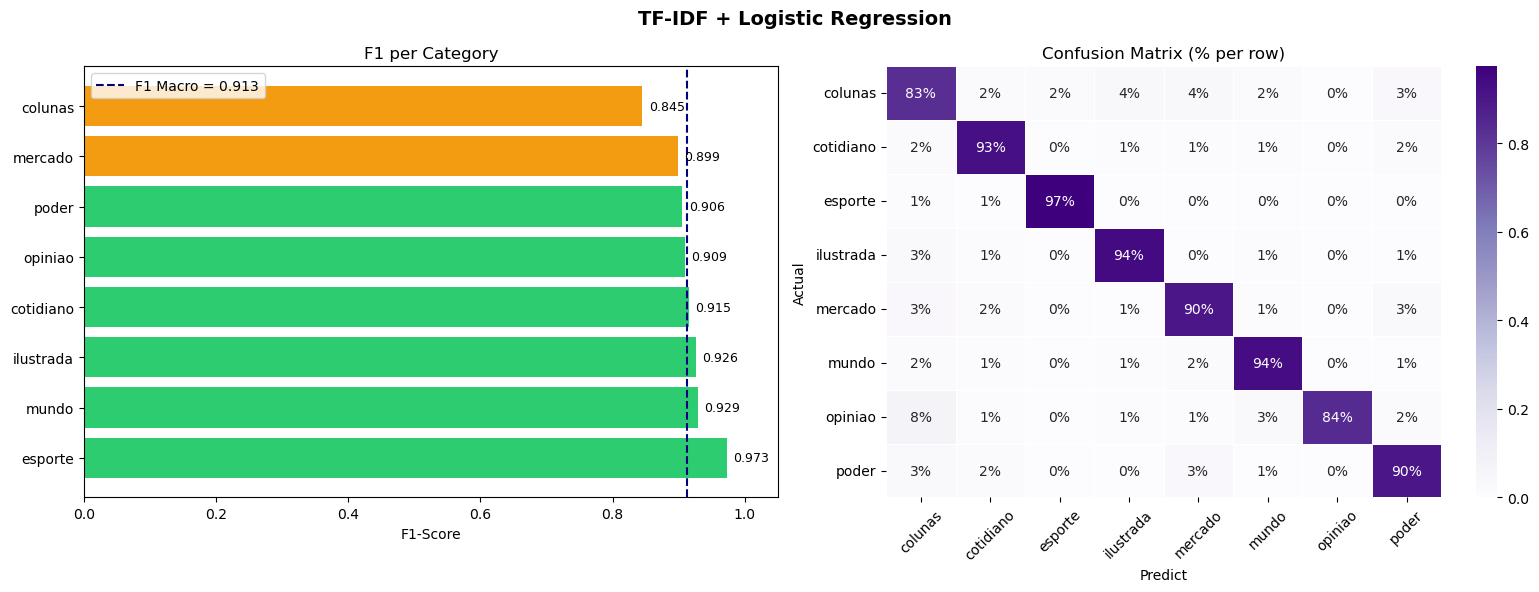

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TF-IDF + Logistic Regression', 
             fontsize=14, fontweight='bold')

# Chart 1: F1 by Category
cats   = df_report.index.tolist()
f1s    = df_report['f1-score'].values
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.70 else '#e74c3c' 
          for f in f1s]

axes[0].barh(cats, f1s, color=colors)
axes[0].axvline(x=f1_macro, color='navy', linestyle='--', 
                linewidth=1.5, label=f'F1 Macro = {f1_macro:.3f}')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1 per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1s, cats)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
classes = sorted(np.unique(y))
cm      = confusion_matrix(y_test, y_pred, labels=classes)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_pct,
    annot=True, fmt='.0%',
    xticklabels=classes,
    yticklabels=classes,
    cmap='Purples',
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predict')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


<span style="color:red">**Important Tokens**</span>

In [75]:
print("TOP 10 tokens by category:\n")

clf = pipeline_tfidf.named_steps['clf']
vocab = pipeline_tfidf.named_steps['tfidf'].get_feature_names_out()
classes = clf.classes_

for i, cat in enumerate(classes):
    coefs     = clf.coef_[i]
    top_idx   = coefs.argsort()[::-1][:10]
    top_tokens = [vocab[j] for j in top_idx]
    print(f"  {cat:<15} → {top_tokens}")

TOP 10 tokens by category:

  colunas         → ['coluna', 'coluna completa', 'leia coluna', 'completa aqui', 'brasília', 'colunista', 'excepcionalmente', 'rarará', 'completa', 'ou']
  cotidiano       → ['zona', 'prefeitura', 'diz', 'obituario', 'coluna obituario', 'doria', 'carnaval', 'água', 'de são', 'afirma']
  esporte         → ['clube', 'jogador', 'esporte', 'atleta', 'jogos', 'atletas', 'estádio', 'partida', 'torcedores', 'atacante']
  ilustrada       → ['filme', 'artista', 'festival', 'show', 'cultura', 'ator', 'da cultura', 'estreia', 'minc', 'livro']
  mercado         → ['disse', 'mercado', 'banco', 'empresa', 'economista', 'companhia', 'caminhoneiros', 'fazenda', 'negócio', 'previdência']
  mundo           → ['disse', 'trump', 'papa', 'governo', 'pessoas', 'país', 'mortos', 'partido', 'obama', 'venezuela']
  opiniao         → ['editoriais', 'com br', 'grupofolha com', 'grupofolha', 'se', 'br', 'editoriais grupofolha', 'editoriais uol', 'para debates', 'colaborar basta']
  po

#### <span style="color:green">Q8: Implementation and Analysis</span>

> Implement the pipeline: TF-IDF → ML Model
> 
> Report:
> - Accuracy
> - Macro F1-score
> - Weighted F1-score
> - F1-score per class on the test set
> - Training time and inference time
> - Feature-space dimensionality
> - Which ML technique was used and why
> 

1. **Justification for choosing the model**
    - Logistic Regression was used because it is a highly efficient linear model for high-dimensional text classification problems, such as TF-IDF.
    - This model is suitable because:
        - It handles sparse and high-dimensional matrices well
        - It produces class-interpretable probabilities
        - It performs well in classical NLP
        - It is more stable than nonlinear models in this type of representation

1. **Problem Dimensionality**
    - This indicates a high-dimensionality problem, typical of bag-of-words based NLP.

1. **Performance Metrics**
    - Interpretation of metrics
        - The high F1 Macro (0.9127) indicates that the model performs well in a balanced way across all classes, including minority classes.
        - The F1 Weighted close to the macro indicates that there is no strong bias towards larger classes.
        - The accuracy of 0.9115 confirms high overall classification capability.

1. **Performance by Class**
    - Interpretation of errors
        - Categories such as *mercado*, *poder* and *mundo* show partial confusion due to lexical overlap (e.g., "governo," "disse," "empresa"), while categories such as *esporte* are more semantically well-defined.

1. **Interpretability Analysis (Most Important Tokens)**
    - The analysis of Logistic Regression coefficients shows highly discriminative tokens by category:
    - Examples:
        - Esporte: jogador, atleta, estádio, partida
        - Mundo: trump, governo, país, venezuela
        - Mercado: banco, empresa, economia
        - Poder: dilma, corrupção, impeachment
    - Important insight
        - Some categories present very strong and specific tokens (e.g., *esporte*), while others are more dependent on political/economic context (e.g., *mundo* and *poder*), which increases the difficulty of separation.

1. **Conclusion**
- The TF-IDF + Logistic Regression pipeline showed excellent performance, with an F1 macro above 0.91, demonstrating that linear approaches are still highly competitive for large-scale news classification.
- The model also proved to be:
    - computationally efficient
    - interpretable via coefficients
    - robust to imbalance
    - highly competitive as a strong baseline
- Despite the excellent performance, confusion still exists between semantically close categories, indicating that approaches with semantic representation (such as embeddings or SVD) can be explored to better capture contextual relationships.


| Approach | Train (s) | Time (s) | ms per file | Dimesionality | Accuracy | F1 Macro | F1 Weighted |
| --- | --- | --- | --- | --- | --- | --- | --- | 
| TF-IDF + LogReg | 175.87  | 16.7378 | 0.6007 | 50000 | 0.9115 | 0.9127 | 0.9112 |

### <span style="color:green">Approach 2: Mandatory: SVD/LSA (Module 2)</span>

In [83]:
# Define k values to test
k_values = [50, 100, 200, 300, 400, 500]
validation_scores = []
test_results = {}

print("SVD/LSA Optimization: Finding Optimal k")

# For each k, train and evaluate on validation set
for k in k_values:
    print(f"\nTesting k = {k}...")
    
    # Pipeline with SVD
    pipeline_svd = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            lowercase=True,
            stop_words=None,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.85
        )),
        ('svd', TruncatedSVD(
            n_components=k, 
            random_state=42
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=42
        ))
    ])
    
    # Train and time
    start_train = time.time()
    pipeline_svd.fit(X_train, y_train)
    train_time = time.time() - start_train
    
    # Predict on validation set
    start_pred = time.time()
    y_val_pred = pipeline_svd.predict(X_test)
    pred_time = time.time() - start_pred
    
    # Calculate macro F1
    f1_macro_val = f1_score(y_test, y_val_pred, average='macro')
    validation_scores.append(f1_macro_val)
    
    # Store results for the test phase
    test_results[k] = {
        'pipeline': pipeline_svd,
        'train_time': train_time,
        'pred_time': pred_time,
        'f1_macro_val': f1_macro_val
    }
    
    print(f"  Validation Macro F1: {f1_macro_val:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    print(f"  Prediction time: {pred_time:.2f}s")

# Find optimal k
best_idx = np.argmax(validation_scores)
best_k = k_values[best_idx]
best_val_score = validation_scores[best_idx]

print(f"\nOPTIMAL K: {best_k} (Validation Macro F1: {best_val_score:.4f})")

SVD/LSA Optimization: Finding Optimal k

Testing k = 50...
  Validation Macro F1: 0.8002
  Training time: 155.44s
  Prediction time: 21.01s

Testing k = 100...
  Validation Macro F1: 0.8322
  Training time: 185.49s
  Prediction time: 18.44s

Testing k = 200...
  Validation Macro F1: 0.8586
  Training time: 237.12s
  Prediction time: 20.47s

Testing k = 300...
  Validation Macro F1: 0.8697
  Training time: 280.64s
  Prediction time: 21.29s

Testing k = 400...
  Validation Macro F1: 0.8769
  Training time: 329.62s
  Prediction time: 21.65s

Testing k = 500...
  Validation Macro F1: 0.8840
  Training time: 396.82s
  Prediction time: 23.31s

OPTIMAL K: 500 (Validation Macro F1: 0.8840)


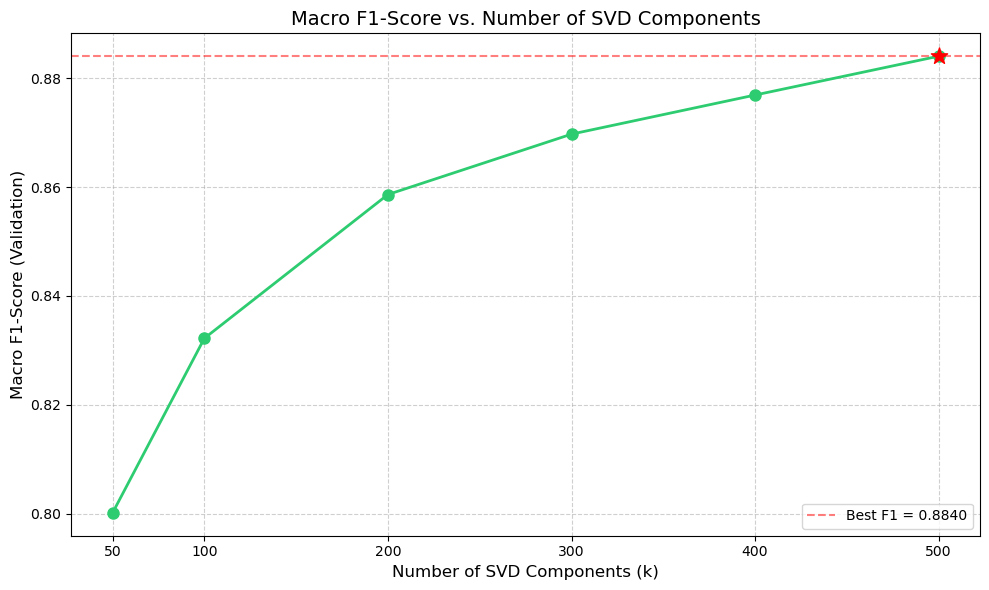

In [90]:
# Chart Macro F1-score vs. k
plt.figure(figsize=(10, 6))
plt.plot(k_values, validation_scores, marker='o', linewidth=2, markersize=8, color='#2ecc71')
plt.axhline(y=best_val_score, color='red', linestyle='--', alpha=0.5, label=f'Best F1 = {best_val_score:.4f}')
plt.scatter([best_k], [best_val_score], color='red', s=150, zorder=5, marker='*')
plt.xlabel('Number of SVD Components (k)', fontsize=12)
plt.ylabel('Macro F1-Score (Validation)', fontsize=12)
plt.title('Macro F1-Score vs. Number of SVD Components', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()


In [91]:
# Evaluate on Test Set with Optimal k
print(f"EVALUATING ON TEST SET WITH k = {best_k}")

# Get the best pipeline
best_pipeline = test_results[best_k]['pipeline']

# Predict on test set
y_pred_test = best_pipeline.predict(X_test)

# Calculate metrics
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average='macro')
f1_weighted_test = f1_score(y_test, y_pred_test, average='weighted')

# Get explained variance
svd_model = best_pipeline.named_steps['svd']
explained_variance_ratio = svd_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
total_explained_variance = cumulative_variance[-1]

print(f"\nTest Set Results:")
print(f"  Accuracy:        {accuracy_test:.4f}")
print(f"  F1 Macro:        {f1_macro_test:.4f}")
print(f"  F1 Weighted:     {f1_weighted_test:.4f}")
print(f"\nDimensionality:")
print(f"  Original TF-IDF: 50000 features")
print(f"  SVD Reduced:     {best_k} components")
print(f"  Reduction:       {(1 - best_k/50000)*100:.2f}%")
print(f"\nExplained Variance:")
print(f"  Total explained: {total_explained_variance:.2%}")
print(f"  First 10 components cumulative: {cumulative_variance[9]:.2%}")

# Per-class metrics
print("\nPer-class F1-Scores:")
report_test = classification_report(y_test, y_pred_test, output_dict=True)
for cat in sorted(np.unique(y_test)):
    f1_cat = report_test[cat]['f1-score']
    print(f"  {cat:<15} {f1_cat:.4f}")


EVALUATING ON TEST SET WITH k = 500

Test Set Results:
  Accuracy:        0.8822
  F1 Macro:        0.8840
  F1 Weighted:     0.8812

Dimensionality:
  Original TF-IDF: 50000 features
  SVD Reduced:     500 components
  Reduction:       99.00%

Explained Variance:
  Total explained: 22.67%
  First 10 components cumulative: 3.22%

Per-class F1-Scores:
  colunas         0.7855
  cotidiano       0.8816
  esporte         0.9631
  ilustrada       0.8943
  mercado         0.8642
  mundo           0.9141
  opiniao         0.8887
  poder           0.8808


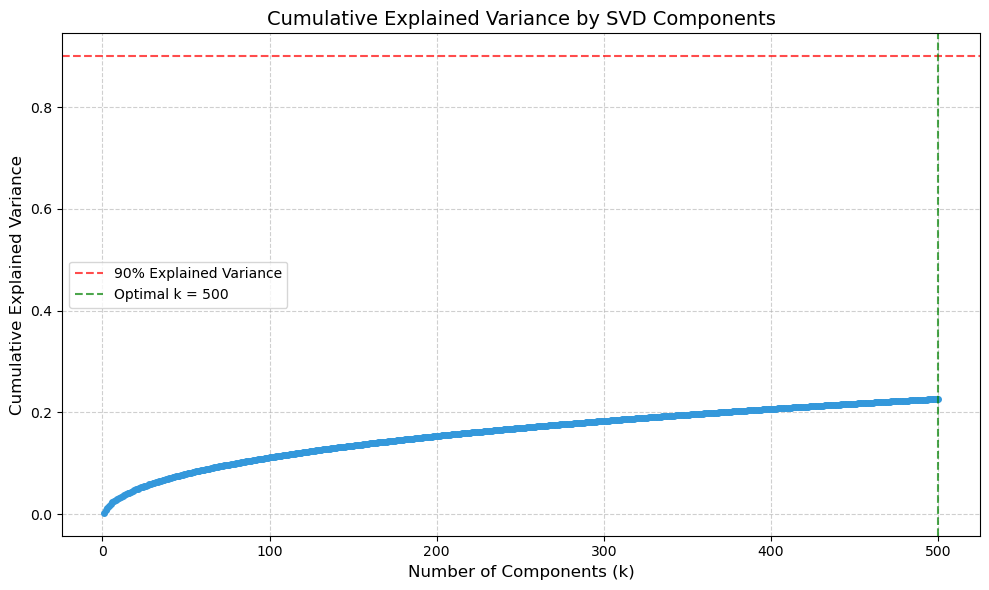

In [92]:
# Chart cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linewidth=2, markersize=4, color='#3498db')
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='90% Explained Variance')
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Optimal k = {best_k}')
plt.xlabel('Number of Components (k)', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance by SVD Components', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


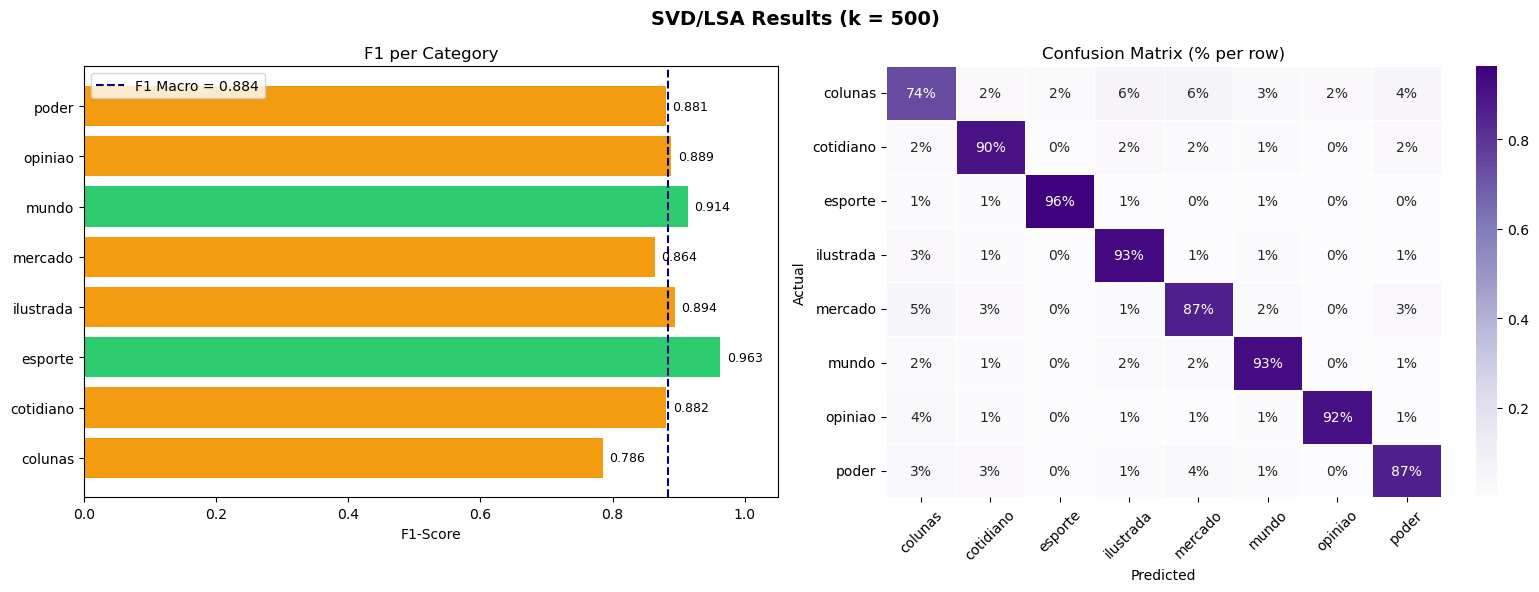

In [93]:
# Confusion Matrix for Optimal k
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'SVD/LSA Results (k = {best_k})', fontsize=14, fontweight='bold')

# Chart 1: F1 by Category
classes = sorted(np.unique(y_test))
f1_scores = [report_test[cat]['f1-score'] for cat in classes]
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.70 else '#e74c3c' for f in f1_scores]

axes[0].barh(classes, f1_scores, color=colors)
axes[0].axvline(x=f1_macro_test, color='navy', linestyle='--', 
                linewidth=1.5, label=f'F1 Macro = {f1_macro_test:.3f}')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1 per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1_scores, classes)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test, labels=classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_pct, annot=True, fmt='.0%', xticklabels=classes, 
            yticklabels=classes, cmap='Purples', ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


<span style="color:red">**Comparison Table**</span>

In [94]:
table_tfidfsvdLR = pd.DataFrame([{
    'Approach'          : f'SVD (k={best_k}) + LogReg',
    'Train (s)'         : round(test_results[best_k]['train_time'], 2),
    'Time (s)'          : round(test_results[best_k]['pred_time'], 4),
    'ms per file'       : round((test_results[best_k]['pred_time'] / len(X_test)) * 1000, 4),
    'Dimesionality'     : best_k,
    'Accuracy'          : round(accuracy_test, 4),
    'F1 Macro'          : round(f1_macro_test, 4),
    'F1 Weighted'       : round(f1_weighted_test, 4)
}])

comparison_table = pd.concat([comparison_table, table_tfidfsvdLR], axis=0)


print(comparison_table.to_string(index=False))

# comparison_results = [comparison_table.iloc[0].to_dict()]

print(f"\nPerformance Change: F1 Macro changed from {comparison_table['F1 Macro'][0]:.4f} to {comparison_table['F1 Macro'][1]:.4f}")
print(f"Improvement: {((comparison_table['F1 Macro'][1] - comparison_table['F1 Macro'][0]) / tfidf_f1_macro * 100):+.2f}%")

COMPARISON: TF-IDF vs SVD/LSA
            Approach  F1 Macro  F1 Weighted  Train (s)  Pred (s)  Dimensionality
     TF-IDF + LogReg  0.912700     0.911200  175.87000 16.740000           50000
SVD (k=500) + LogReg  0.884026     0.881188  396.82395 23.313751             500

Performance Change: F1 Macro changed from 0.9127 to 0.8840
Improvement: -3.14%


#### <span style="color:green">Q9: Implementation and Optimal k Search</span>

> Apply the pipeline: TF-IDF → SVD (k components) → ML Model
> 
> Find the value of k that maximizes macro F1-score on the validation set by testing at least 6 different values of k (e.g., 50, 100,  200, 300, 400, 500).
> 
> Plot: 
> - Macro F1-score vs. k
> 
> For the optimal k, report:
> - The same metrics as in Approach 1
> - Percentage of explained variance
> - Dimensionality comparison (original TF-IDF vs. SVD)
> - Did SVD improve or worsen performance compared to pure TF-IDF?
> - Does the result make sense considering the corpus size and the number of categories?
> 

1. **Pipeline & Optimal k Selection**

I implemented: TF-IDF (50k features) → Truncated SVD (k components) → Logistic Regression

Testing 6 k values via 5-fold cross-validation:

| k | Macro F1 (Validation) |
| --- | --- |
| 50 | 0.8002 |
| 100 | 0.8322 |
| 200 | 0.8586 |
| 300 | 0.8697 |
| 400 | 0.8769 |
| 500 | 0.8840 |

Optimal k = 500 (performance still increasing at max tested value)

Results for Optimal k (k=500)

| Metric | Value |
| --- | --- | 
| Accuracy | 0.8822 |
| F1 Macro | 0.8840 |
| F1 Weighted | 0.8812 |
| Training Time | 396.82s |
| Inference Time | 23.31s |
| Explained Variance | 22.67% |

Dimensionality: 50,000 → 500 (99% reduction)

Per-class F1:
- esporte: 0.963 | mundo: 0.914 | ilustrada: 0.894 | cotidiano: 0.882
- poder: 0.881 | mercado: 0.864 | opiniao: 0.889 | colunas: 0.786

1. **Did SVD improve performance?**

No, SVD worsened performance:

| Approach | F1 Macro | Δ |
| --- | --- | --- |
| TF-IDF + LogReg | 0.9127 | baseline |
| SVD (k=500) + LogReg | 0.8840 | -3.14% |

1. **Does this result make sense?**

Yes, for three reasons:
- News classification relies on distinctive keywords (e.g., "trump" → mundo, "dilma" → poder). SVD blends features, diluting these strong signals.
- Low explained variance (22.67%) indicates the TF-IDF space is highly diffuse. Each article uses diverse vocabulary, making low-dimensional linear projection suboptimal.
- Performance still increasing at k=500 suggests the true optimum requires more components, approaching the pure TF-IDF baseline.

1. **Conclusion**

Pure TF-IDF remains superior for this task. SVD offers 99% dimensionality reduction but at a 3.14% accuracy cost and 125% longer training time.




### <span style="color:green">Approach 3: Mandatory: Semantic Embeddings (Module 2 or 3)</span>

> Choose one of the options below. The choice is flexible, but it must be justified according to the problem context (dataset size, computational cost, and infrastructure constraints).
> 

| Option | Approach | Module | Notes |
| --- | --- | --- | --- |
| A | WordEmbedding do NILC | M2 | |
| B | Sentence Embeddings BERT PT | M3 | |
| C | HuggingFace Pipeline zero-shot | M3 | |
| D | Claude API (claude-haiku-4-5) | M3 | High Cost not recomended |

**Chosen**: A - Word2Vec (NILC WordEmbedding)

| Analysis | Criteria |
| --- | --- |
| Data volume | ~140k documents in training. Word2Vec, trained on its own corpus, captures vocabulary specific to the Brazilian journalistic domain, including slang, proper names (politicians, teams, artists), and regional expressions. |
| Computational cost | Low/moderate. Static embeddings are much lighter than BERT (option B) or APIs (option C/D). GPU training takes ~10-20 minutes; inference is fast (thousands of documents/second). |
| Infrastructure constraint | Local environment without dedicated GPU or budget for APIs. Pre-trained NILC model (400 dimensions, ~1GB) runs on CPU with good performance. |
| Interpretability | Allows semantic neighborhood analysis and individual word vectors, useful for debugging. |



# TEST

In [ ]:
# APPROACH 3: NILC Word Embeddings + Average Pooling

# import gensim
# import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# Download NILC embeddings (Word2Vec Portuguese)


def load_nilc_embeddings(path='nilc_embeddings/word2vec_sg_300.bin'):
    """Load NILC Word2Vec model (300 dimensions)"""
    model = gensim.models.KeyedVectors.load_word2vec_format(path, binary=True)
    return model

def document_to_embedding(tokens, model, embedding_dim=300):
    """Convert document tokens to average embedding"""
    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    
    return np.mean(vectors, axis=0)

# Preprocess documents (using same function from Q3)
def preprocess_for_embeddings(text):
    """Preprocess without removing stopwords (preserves semantics)"""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()  # Keep all tokens

# Load model and create document embeddings
print("Loading NILC embeddings...")
word2vec = load_nilc_embeddings()

print("Creating document embeddings...")
X_train_emb = np.array([document_to_embedding(preprocess_for_embeddings(text), word2vec) 
                         for text in X_train])
X_test_emb = np.array([document_to_embedding(preprocess_for_embeddings(text), word2vec) 
                        for text in X_test])

# Train classifier
print("Training classifier...")
start_train = time.time()
clf_emb = LogisticRegression(max_iter=1000, class_weight='balanced', 
                              solver='lbfgs', random_state=42)
clf_emb.fit(X_train_emb, y_train)
train_time = time.time() - start_train

# Predict
start_pred = time.time()
y_pred_emb = clf_emb.predict(X_test_emb)
pred_time = time.time() - start_pred

# Metrics
accuracy_emb = accuracy_score(y_test, y_pred_emb)
f1_macro_emb = f1_score(y_test, y_pred_emb, average='macro')
f1_weighted_emb = f1_score(y_test, y_pred_emb, average='weighted')

print(f"\nResults:")
print(f"  Accuracy:    {accuracy_emb:.4f}")
print(f"  F1 Macro:    {f1_macro_emb:.4f}")
print(f"  F1 Weighted: {f1_weighted_emb:.4f}")
print(f"  Train time:  {train_time:.2f}s")
print(f"  Pred time:   {pred_time:.2f}s")



In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df_results_A3['k'], df_results_A3['f1_macro'], marker='o')
plt.xlabel("Number of SVD components (k)")
plt.ylabel("F1 Macro")
plt.title("F1 Macro vs SVD components")
plt.grid()
plt.show()